# The following code is to answer the question:
**Q4:** What time lags exist between changes in meteorological and hydrological variables and observed flooding?

This will be done in the following steps:
**1:** Load flood observations
**2:** Create daily flood time series
**3:** Restrict floods to ERA5 overlap
**4:** Inspect ERA5 variables                     
**5:** Confirm temporal structure
**6:** Determine accumulation behaviour
**7:** Create daily rainfall series
**8:** Create daily runoff series
**9:** Compare rainfall/runoff with flooding
**10:** Calculate time lags

note that most steps will have multiple cells

In [1]:
from pathlib import Path
import sys
import os

NOTEBOOK_DIR = Path.cwd().resolve()

print("Notebook directory:")
print(NOTEBOOK_DIR)

PROJECT_ROOT = NOTEBOOK_DIR.parent

print("\nProject root:")
print(PROJECT_ROOT)

os.chdir(PROJECT_ROOT)

processing_data_path = PROJECT_ROOT / "processing_data"

if str(processing_data_path) not in sys.path:
    sys.path.insert(0, str(processing_data_path))

print("\nCurrent working directory:")
print(Path.cwd())

Notebook directory:
C:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026\notebooks

Project root:
C:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026

Current working directory:
C:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026


In [2]:
print("Contents of raw_data:")

raw_data_path = PROJECT_ROOT / "raw_data"

if raw_data_path.exists():
    for item in raw_data_path.iterdir():
        print("-", item.name)
else:
    print("raw_data folder not found!")

Contents of raw_data:
- Administrative boundaries
- Darthmouth Flood Observatory
- evapotranspiration
- farmland
- flood_masks
- GDP
- health facilities
- IPC
- OSM
- rainfall and runoff
- Water levels lakes
- worldpop


In [3]:
# Imports needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from loading import load_flood_masks

In [4]:
# Settings
YEARS = [2020]

In [38]:
## FOR THIS CELL TO WORK, ONLY RUN THE CELLS ABOVE ONCE, ELSE RESTART THE KERNEL AND RUN ALL CELLS ABOVE THIS ONE ONCE ##

flood_path = PROJECT_ROOT / "raw_data" / "flood_masks"

print("Flood mask folder exists:", flood_path.exists())
print("Flood mask path:")
print(flood_path)

print("\nContents:")
for item in flood_path.iterdir():
    print("-", item.name)

Flood mask folder exists: True
Flood mask path:
C:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026\raw_data\flood_masks

Contents:
- compact_recurring
- compact_unusual


In [6]:
floods = load_flood_masks(years=YEARS)
print("--- FLOOD DATA ---")
print(floods.head())
print("\nColumns:")
print(floods.columns)
print("\nData information:")
floods.info()

--- FLOOD DATA ---
        date       lat        lon    tile  flood_type
0 2020-01-01  0.003125  32.226040  h21v08           1
1 2020-01-01  0.034375  32.265625  h21v08           0
2 2020-01-01  0.086458  33.488541  h21v08           0
3 2020-01-01  0.096875  32.709373  h21v08           0
4 2020-01-01  0.136458  33.801041  h21v08           0

Columns:
Index(['date', 'lat', 'lon', 'tile', 'flood_type'], dtype='str')

Data information:
<class 'pandas.DataFrame'>
RangeIndex: 4765044 entries, 0 to 4765043
Data columns (total 5 columns):
 #   Column      Dtype         
---  ------      -----         
 0   date        datetime64[us]
 1   lat         float32       
 2   lon         float32       
 3   tile        str           
 4   flood_type  int64         
dtypes: datetime64[us](1), float32(2), int64(1), str(1)
memory usage: 173.3 MB


In [7]:
# Create daily flood time series
daily_floods = (floods.groupby('date').size().reset_index(name='flood_pixels'))
print("\n--- DAILY FLOOD TIME SERIES ---")
print(daily_floods.head())
print(daily_floods.tail())
print("\nNumber of days with flood pixels observed:")
print(len(daily_floods))


--- DAILY FLOOD TIME SERIES ---
        date  flood_pixels
0 2020-01-01         15010
1 2020-01-02         18439
2 2020-01-03         11179
3 2020-01-04          8286
4 2020-01-05         12064
          date  flood_pixels
359 2020-12-27         32823
360 2020-12-28         45440
361 2020-12-29         46468
362 2020-12-30         32527
363 2020-12-31         50111

Number of days with flood pixels observed:
364


In [8]:
# Create a complete daily timeline
all_dates = pd.date_range(start="2020-01-01", end="2020-12-31", freq="D")
daily_floods= (daily_floods.set_index("date").reindex(all_dates, fill_value=0))
daily_floods.index.name = "date"
print("\n--- COMPLETE DAILY FLOOD TIME SERIES ---")
print(daily_floods.head(10))
print(daily_floods.tail(10))
print(daily_floods['flood_pixels'].describe())


--- COMPLETE DAILY FLOOD TIME SERIES ---
            flood_pixels
date                    
2020-01-01         15010
2020-01-02         18439
2020-01-03         11179
2020-01-04          8286
2020-01-05         12064
2020-01-06         12558
2020-01-07         22041
2020-01-08         13096
2020-01-09         24983
2020-01-10         22325
            flood_pixels
date                    
2020-12-22         26195
2020-12-23         20458
2020-12-24         30242
2020-12-25         25854
2020-12-26         52191
2020-12-27         32823
2020-12-28         45440
2020-12-29         46468
2020-12-30         32527
2020-12-31         50111
count      366.000000
mean     13019.245902
std      12933.011284
min          0.000000
25%       3309.500000
50%       7688.500000
75%      20511.000000
max      54769.000000
Name: flood_pixels, dtype: float64


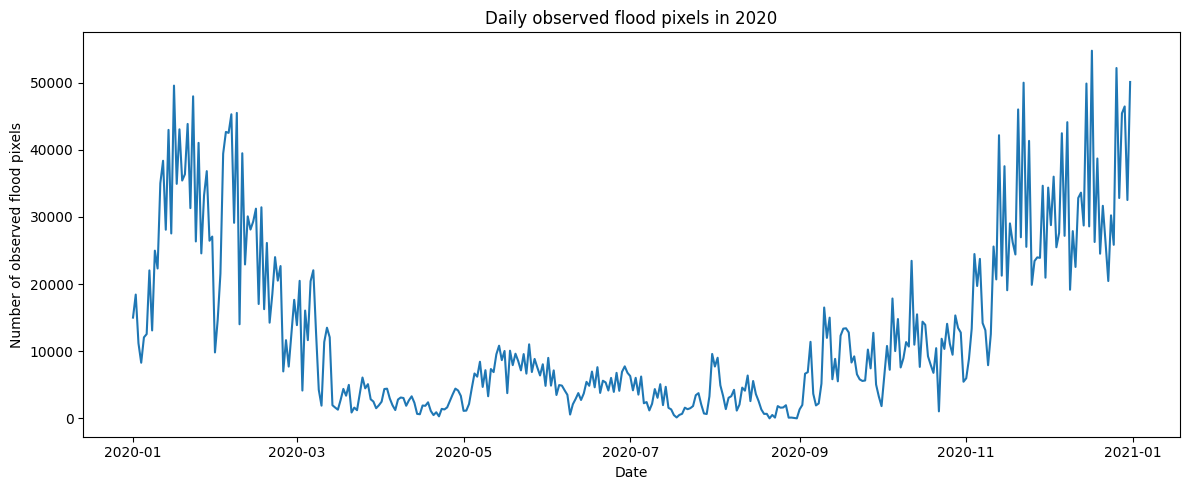

In [9]:
# Visualize daily flood activity
plt.figure(figsize=(12, 5))
plt.plot(daily_floods.index, daily_floods["flood_pixels"])
plt.xlabel("Date")
plt.ylabel("Number of observed flood pixels")
plt.title("Daily observed flood pixels in 2020")
plt.tight_layout()
plt.show()

In [10]:
# Inspect flood spatial extent
print("\n--- FLOOD SPATIAL EXTENT ---")
print("Latitude range:")
print(floods["lat"].min(), "to", floods["lat"].max())
print("\nLongitude range:")
print(floods["lon"].min(), "to", floods["lon"].max())
print("\nFlood observations per tile:")
print(floods["tile"].value_counts())


--- FLOOD SPATIAL EXTENT ---
Latitude range:
0.0010416667 to 9.998959

Longitude range:
20.001041 to 39.99896

Flood observations per tile:
tile
h21v08    3911778
h20v08     853266
Name: count, dtype: int64


In [11]:
# Flood activity by modis tile
daily_flood_tile = (floods.groupby(["date", "tile"]).size().reset_index(name="flood_pixels"))
    # Pivot so each tile becomes a separate column
daily_flood_tile = daily_flood_tile.pivot(index="date", columns="tile", values="flood_pixels")
    # Add missing dates and replace missing observations with 0
daily_flood_tile = daily_flood_tile.reindex(all_dates, fill_value=0)
daily_flood_tile.index.name = "date"
print("\n--- DAILY FLOOD ACTIVITY BY TILE ---")
print(daily_flood_tile.head())


--- DAILY FLOOD ACTIVITY BY TILE ---
tile        h20v08   h21v08
date                       
2020-01-01  9059.0   5951.0
2020-01-02  4598.0  13841.0
2020-01-03  4081.0   7098.0
2020-01-04  1400.0   6886.0
2020-01-05  6541.0   5523.0


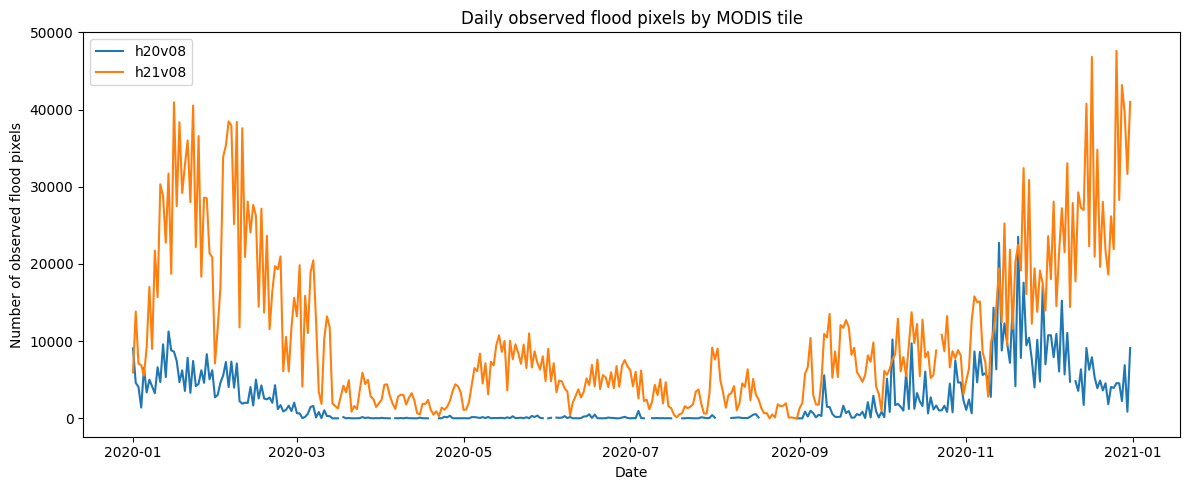

In [12]:
plt.figure(figsize=(12, 5))
for tile in daily_flood_tile.columns:plt.plot(daily_flood_tile.index, daily_flood_tile[tile], label=tile)
plt.xlabel("Date")
plt.ylabel("Number of observed flood pixels")
plt.title("Daily observed flood pixels by MODIS tile")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Inspect rainfall and runoff data
rainfall_runoff_path = (PROJECT_ROOT / "raw_data" / "rainfall and runoff")
print("Rainfall and runoff folder exists:", rainfall_runoff_path.exists())
print("\nContents:")
for item in rainfall_runoff_path.iterdir():
    print("-", item.name)

Rainfall and runoff folder exists: True

Contents:
- ERA5_2000.nc
- ERA5_2001.nc
- ERA5_2002.nc
- ERA5_2003.nc
- ERA5_2004.nc
- ERA5_2005.nc
- ERA5_2006.nc
- ERA5_2007.nc
- ERA5_2008.nc
- ERA5_2009.nc
- ERA5_2010.nc
- ERA5_2011.nc
- ERA5_2012.nc
- ERA5_2013.nc
- ERA5_2014.nc
- ERA5_2015.nc
- ERA5_2016.nc
- ERA5_2017.nc
- ERA5_2018.nc
- ERA5_2019.nc
- ERA5_2020.nc
- ERA5_2021.nc
- ERA5_2022.nc
- ERA5_2023.nc
- ERA5_2024.nc
- ERA5_2025.nc


In [14]:
# Inspect ERA5  rainfall and runoff data
import xarray as xr
era5_path = (PROJECT_ROOT / "raw_data" / "rainfall and runoff" / "ERA5_2020.nc")
era5 = xr.open_dataset(era5_path)
print(era5)

<xarray.Dataset> Size: 581MB
Dimensions:     (valid_time: 8784, latitude: 145, longitude: 57)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2020-01-01 ... 2020-12-31T23...
    expver      (valid_time) <U4 141kB ...
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 290MB ...
    ro          (valid_time, latitude, longitude) float32 290MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-31T21:34 GRIB to CDM+CF via cfgrib-0.9.1...


In [15]:
# Inspect ERA5 variables
print("Data variables:")
print(list(era5.data_vars))
print("\nCoordinates:")
print(list(era5.coords))
print("\nDimensions:")
print(era5.dims)

Data variables:
['tp', 'ro']

Coordinates:
['number', 'valid_time', 'latitude', 'longitude', 'expver']

Dimensions:
FrozenMappingWarningOnValuesAccess({'valid_time': 8784, 'latitude': 145, 'longitude': 57})


In [16]:
# Inspect variable metadata
print("--- TOTAL PRECIPITATION (tp) ---")
print(era5["tp"])
print("\n--- RUNOFF (ro) ---")
print(era5["ro"])

--- TOTAL PRECIPITATION (tp) ---
<xarray.DataArray 'tp' (valid_time: 8784, latitude: 145, longitude: 57)> Size: 290MB
[72599760 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2020-01-01 ... 2020-12-31T23...
    expver      (valid_time) <U4 141kB ...
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      8265
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total

In [17]:
# variable attributes
print("--- tp attributes ---")
print(era5["tp"].attrs)
print("\n--- ro attributes ---")
print(era5["ro"].attrs)

--- tp attributes ---
{'GRIB_paramId': np.int64(228), 'GRIB_dataType': 'fc', 'GRIB_numberOfPoints': np.int64(8265), 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': np.int64(1), 'GRIB_stepType': 'accum', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': np.int64(0), 'GRIB_NV': np.int64(0), 'GRIB_Nx': np.int64(57), 'GRIB_Ny': np.int64(145), 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 'tp', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_iScansNegatively': np.int64(0), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_jPointsAreConsecutive': np.int64(0), 'GRIB_jScansPositively': np.int64(0), 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(33.0), 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(-3.0), 'GRIB_longitudeOfFirstGridPointInDegrees': np.float64(23.0), 'GRIB_longitudeOfLastGridPointInDegrees': np.float64(37.0), 'GRIB_missingValue': np.float64(3.4028234663852886e+38), 'GRIB_name': 'T

In [18]:
# Compare flood and ERA5 spatial coverage
print("--- FLOOD DATA EXTENT ---")
print("Latitude:", floods["lat"].min(), "to", floods["lat"].max())
print("Longitude:", floods["lon"].min(), "to", floods["lon"].max())

print("\n--- ERA5 EXTENT ---")
print("Latitude:", era5.latitude.min().item(), "to", era5.latitude.max().item())
print("Longitude:", era5.longitude.min().item(), "to", era5.longitude.max().item())

--- FLOOD DATA EXTENT ---
Latitude: 0.0010416667 to 9.998959
Longitude: 20.001041 to 39.99896

--- ERA5 EXTENT ---
Latitude: -3.0 to 33.0
Longitude: 23.0 to 37.0


In [19]:
# Check flood pixel coverage by ERA5 
era5_lat_min = era5.latitude.min().item()
era5_lat_max = era5.latitude.max().item()
era5_lon_min = era5.longitude.min().item()
era5_lon_max = era5.longitude.max().item()

floods_in_era5 = floods[floods["lat"].between(era5_lat_min, era5_lat_max)&floods["lon"].between(era5_lon_min, era5_lon_max)]
print("--- FLOOD PIXELS COVERED BY ERA5 ---")
print("Total flood observations:", len(floods) )
print("Flood observations within ERA5 coverage:", len(floods_in_era5))
print("Percentage covered:", round(len(floods_in_era5) / len(floods) * 100, 2),"%")

--- FLOOD PIXELS COVERED BY ERA5 ---
Total flood observations: 4765044
Flood observations within ERA5 coverage: 3983424
Percentage covered: 83.6 %


In [20]:
# Daily flood activity within ERA5 coverage
daily_floods_in_era5 = (floods_in_era5.groupby("date").size().reset_index(name="flood_pixels"))
daily_floods_in_era5["date"] = pd.to_datetime(daily_floods_in_era5["date"])
all_dates = pd.date_range(start="2020-01-01", end="2020-12-31", freq="D")
daily_floods_in_era5 = daily_floods_in_era5.set_index("date").reindex(all_dates, fill_value=0)

daily_floods_in_era5.index.name = "date"
print("\n--- DAILY FLOOD TIME SERIES WITHIN ERA5 COVERAGE ---")
print(daily_floods_in_era5.head(10))
print("\nSummary statistics:")
print(daily_floods_in_era5['flood_pixels'].describe())


--- DAILY FLOOD TIME SERIES WITHIN ERA5 COVERAGE ---
            flood_pixels
date                    
2020-01-01          9275
2020-01-02         15130
2020-01-03          9923
2020-01-04          6058
2020-01-05          9943
2020-01-06          8930
2020-01-07         18955
2020-01-08          8750
2020-01-09         21669
2020-01-10         18426

Summary statistics:
count      366.000000
mean     10883.672131
std      11607.443687
min          0.000000
25%       2348.750000
50%       6049.000000
75%      16781.500000
max      48445.000000
Name: flood_pixels, dtype: float64


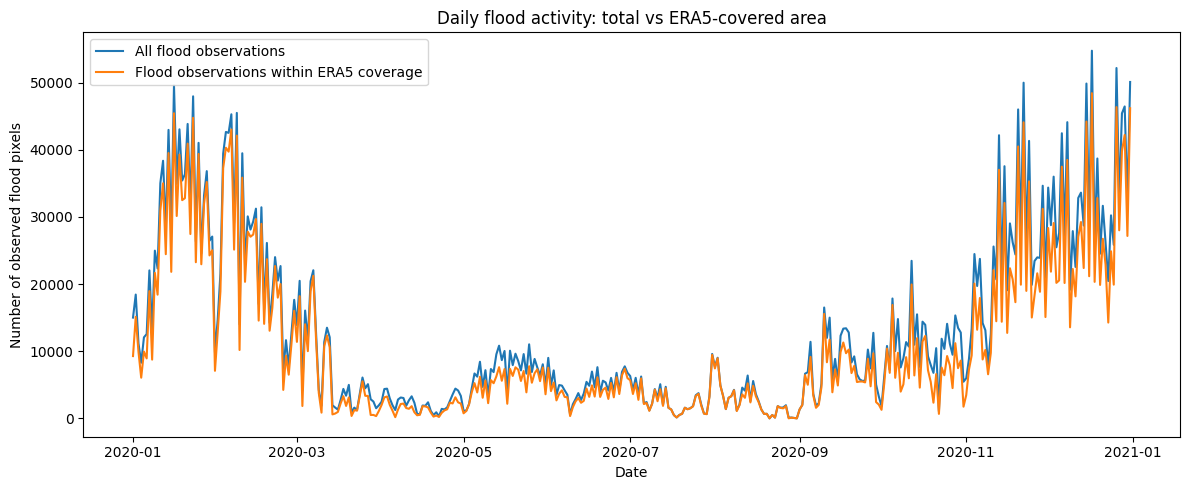

In [21]:
# compare total and ERA5 covered flood activity
plt.figure(figsize=(12, 5))
plt.plot(daily_floods.index, daily_floods["flood_pixels"], label="All flood observations")
plt.plot(daily_floods_in_era5.index, daily_floods_in_era5["flood_pixels"], label="Flood observations within ERA5 coverage")
plt.xlabel("Date")
plt.ylabel("Number of observed flood pixels")
plt.title("Daily flood activity: total vs ERA5-covered area")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Inspect hourly ERA5 values at one location
# Select a location approximately in the middle of the
# flood-study area and within ERA5 coverage
sample_era5 = era5.sel(latitude=5, longitude=30, method="nearest")
# Select the first three days of 2020
sample_period = sample_era5.sel(valid_time=slice("2020-01-01", "2020-01-03"))
# Convert to a DataFrame
sample_df = sample_period[["tp", "ro"]].to_dataframe()
print("--- SAMPLE ERA5 HOURLY VALUES ---")
print(sample_df.head(30))

--- SAMPLE ERA5 HOURLY VALUES ---
                      tp        ro  number  latitude  longitude expver
valid_time                                                            
2020-01-01 00:00:00  0.0  0.000024       0       5.0       30.0   0001
2020-01-01 01:00:00  0.0  0.000024       0       5.0       30.0   0001
2020-01-01 02:00:00  0.0  0.000024       0       5.0       30.0   0001
2020-01-01 03:00:00  0.0  0.000024       0       5.0       30.0   0001
2020-01-01 04:00:00  0.0  0.000024       0       5.0       30.0   0001
2020-01-01 05:00:00  0.0  0.000024       0       5.0       30.0   0001
2020-01-01 06:00:00  0.0  0.000024       0       5.0       30.0   0001
2020-01-01 07:00:00  0.0  0.000024       0       5.0       30.0   0001
2020-01-01 08:00:00  0.0  0.000024       0       5.0       30.0   0001
2020-01-01 09:00:00  0.0  0.000024       0       5.0       30.0   0001
2020-01-01 10:00:00  0.0  0.000024       0       5.0       30.0   0001
2020-01-01 11:00:00  0.0  0.000024       0 

In [23]:
# Convert sample values to millimetre
sample_mm = sample_df.copy()
sample_mm["tp_mm"] = sample_mm["tp"] * 1000
sample_mm["ro_mm"] = sample_mm["ro"] * 1000
print("--- SAMPLE ERA5 VALUES IN MILLIMETRES ---")
print(sample_mm[["tp_mm", "ro_mm"]].head(30))

--- SAMPLE ERA5 VALUES IN MILLIMETRES ---
                     tp_mm     ro_mm
valid_time                          
2020-01-01 00:00:00    0.0  0.024319
2020-01-01 01:00:00    0.0  0.024319
2020-01-01 02:00:00    0.0  0.024319
2020-01-01 03:00:00    0.0  0.024319
2020-01-01 04:00:00    0.0  0.024080
2020-01-01 05:00:00    0.0  0.024319
2020-01-01 06:00:00    0.0  0.024319
2020-01-01 07:00:00    0.0  0.023842
2020-01-01 08:00:00    0.0  0.023842
2020-01-01 09:00:00    0.0  0.023842
2020-01-01 10:00:00    0.0  0.023842
2020-01-01 11:00:00    0.0  0.023842
2020-01-01 12:00:00    0.0  0.023842
2020-01-01 13:00:00    0.0  0.023842
2020-01-01 14:00:00    0.0  0.023842
2020-01-01 15:00:00    0.0  0.023842
2020-01-01 16:00:00    0.0  0.023842
2020-01-01 17:00:00    0.0  0.023842
2020-01-01 18:00:00    0.0  0.023842
2020-01-01 19:00:00    0.0  0.023842
2020-01-01 20:00:00    0.0  0.023842
2020-01-01 21:00:00    0.0  0.023842
2020-01-01 22:00:00    0.0  0.023842
2020-01-01 23:00:00    0.0  0.023

In [24]:
# Find hours with precipitation

# Maximum precipitation across all ERA5 grid cells per hour
tp_hourly_max = era5["tp"].max( dim=["latitude", "longitude"])
# Convert to millimetres
tp_hourly_max_mm = tp_hourly_max * 1000
# Convert to DataFrame
tp_max_df = tp_hourly_max_mm.to_dataframe( name="max_tp_mm")
# Show hours with the largest precipitation
print(tp_max_df.sort_values("max_tp_mm", ascending=False).head(20))

                     number expver  max_tp_mm
valid_time                                   
2020-08-31 16:00:00       0   0001  71.634293
2020-09-06 15:00:00       0   0001  70.739746
2020-09-09 16:00:00       0   0001  69.757462
2020-07-25 15:00:00       0   0001  69.728851
2020-09-06 16:00:00       0   0001  69.551468
2020-06-18 15:00:00       0   0001  66.524506
2020-09-09 14:00:00       0   0001  66.303253
2020-07-22 14:00:00       0   0001  65.032959
2020-09-09 15:00:00       0   0001  64.880371
2020-01-31 16:00:00       0   0001  64.350128
2020-09-05 15:00:00       0   0001  64.163208
2020-10-17 14:00:00       0   0001  63.512802
2020-07-24 14:00:00       0   0001  62.908173
2020-05-07 15:00:00       0   0001  62.898636
2020-01-31 15:00:00       0   0001  62.757492
2020-06-21 16:00:00       0   0001  61.902046
2020-08-31 17:00:00       0   0001  61.387062
2020-08-20 15:00:00       0   0001  60.893059
2020-07-25 14:00:00       0   0001  60.719490
2020-06-30 15:00:00       0   0001

In [25]:
# Find location of maximum precipitation

# Find the time with maximum precipitation
max_time = pd.Timestamp(tp_hourly_max_mm.idxmax().values)
# ERA5 precipitation field at that time
tp_at_max_time = (era5["tp"].sel(valid_time=max_time) * 1000)
# Find the position of the maximum value in the 2D grid
max_index = np.unravel_index(tp_at_max_time.values.argmax(), tp_at_max_time.shape)
# Convert array indices to latitude and longitude
lat_index = max_index[0]
lon_index = max_index[1]
rainy_lat = float(tp_at_max_time.latitude.values[lat_index])
rainy_lon = float(tp_at_max_time.longitude.values[lon_index])
max_precipitation = float(tp_at_max_time.values.max())

print("--- MAXIMUM PRECIPITATION EVENT ---")
print("Time:")
print(max_time)
print("\nLatitude:")
print(rainy_lat)
print("\nLongitude:")
print(rainy_lon)
print("\nMaximum precipitation (mm):")
print(max_precipitation)

--- MAXIMUM PRECIPITATION EVENT ---
Time:
2020-08-31 16:00:00

Latitude:
3.5

Longitude:
34.0

Maximum precipitation (mm):
71.63429260253906


In [26]:
rainy_sample = era5.sel(latitude=rainy_lat, longitude=rainy_lon, method="nearest")
rainy_df = rainy_sample[["tp", "ro"]].to_dataframe()

rainy_df["tp_mm"] = rainy_df["tp"] * 1000
rainy_df["ro_mm"] = rainy_df["ro"] * 1000

event_start = max_time - pd.Timedelta(hours=12)
event_end = max_time + pd.Timedelta(hours=12)
event_df = rainy_df.loc[event_start:event_end, ["tp_mm", "ro_mm"]]

print("--- RAINFALL EVENT ---")
print(event_df)

--- RAINFALL EVENT ---
                         tp_mm      ro_mm
valid_time                               
2020-08-31 04:00:00   0.000000   0.124454
2020-08-31 05:00:00   0.005722   0.124454
2020-08-31 06:00:00   0.067234   0.125408
2020-08-31 07:00:00   0.068188   0.124931
2020-08-31 08:00:00   0.157833   0.126123
2020-08-31 09:00:00   0.374794   0.129700
2020-08-31 10:00:00   0.817776   0.135899
2020-08-31 11:00:00   1.487255   0.148296
2020-08-31 12:00:00   5.870819   1.756191
2020-08-31 13:00:00  10.594368   6.214619
2020-08-31 14:00:00  31.140327  26.303291
2020-08-31 15:00:00  53.213120  48.611641
2020-08-31 16:00:00  71.634293  67.405701
2020-08-31 17:00:00  61.387062  57.461739
2020-08-31 18:00:00  51.086426  47.246933
2020-08-31 19:00:00   1.091003   0.199080
2020-08-31 20:00:00   0.020981   0.127792
2020-08-31 21:00:00   0.082016   0.137806
2020-08-31 22:00:00   0.037670   0.134468
2020-08-31 23:00:00   0.003338   0.130415
2020-09-01 00:00:00   0.000000   0.131607
2020-09-01 

In [27]:
# Inspect ERA5 time/forecast structure
print("--- DATASET COORDINATES ---")
for coord in era5.coords:
    print(f"\n{coord}:")
    print(era5[coord])

--- DATASET COORDINATES ---

number:
<xarray.DataArray 'number' ()> Size: 8B
array(0)
Coordinates:
    number   int64 8B 0
Attributes:
    long_name:      ensemble member numerical id
    units:          1
    standard_name:  realization

valid_time:
<xarray.DataArray 'valid_time' (valid_time: 8784)> Size: 70kB
array(['2020-01-01T00:00:00.000000000', '2020-01-01T01:00:00.000000000',
       '2020-01-01T02:00:00.000000000', ..., '2020-12-31T21:00:00.000000000',
       '2020-12-31T22:00:00.000000000', '2020-12-31T23:00:00.000000000'],
      shape=(8784,), dtype='datetime64[ns]')
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2020-01-01 ... 2020-12-31T23...
    expver      (valid_time) <U4 141kB '0001' '0001' '0001' ... '0001' '0001'
    number      int64 8B 0
Attributes:
    long_name:      time
    standard_name:  time

latitude:
<xarray.DataArray 'latitude' (latitude: 145)> Size: 1kB
array([33.  , 32.75, 32.5 , 32.25, 32.  , 31.75, 31.5 , 31.25, 31.  , 30.75,
       30.5 

In [28]:
# Check time structure
times = pd.to_datetime(era5["valid_time"].values)

print("Number of timestamps:", len(times))
print("Number of unique timestamps:", len(pd.unique(times)))

print("\nFirst 10 timestamps:")
print(times[:10])

print("\nLast 10 timestamps:")
print(times[-10:])

print("\nTime differences:")
print(pd.Series(times).diff().value_counts().head())

Number of timestamps: 8784
Number of unique timestamps: 8784

First 10 timestamps:
DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 01:00:00',
               '2020-01-01 02:00:00', '2020-01-01 03:00:00',
               '2020-01-01 04:00:00', '2020-01-01 05:00:00',
               '2020-01-01 06:00:00', '2020-01-01 07:00:00',
               '2020-01-01 08:00:00', '2020-01-01 09:00:00'],
              dtype='datetime64[ns]', freq=None)

Last 10 timestamps:
DatetimeIndex(['2020-12-31 14:00:00', '2020-12-31 15:00:00',
               '2020-12-31 16:00:00', '2020-12-31 17:00:00',
               '2020-12-31 18:00:00', '2020-12-31 19:00:00',
               '2020-12-31 20:00:00', '2020-12-31 21:00:00',
               '2020-12-31 22:00:00', '2020-12-31 23:00:00'],
              dtype='datetime64[ns]', freq=None)

Time differences:
0 days 01:00:00    8783
Name: count, dtype: int64


In [29]:
# Inspect changes between hourly values
event_check = event_df.copy()
event_check["tp_change_mm"] = event_check["tp_mm"].diff()
event_check["ro_change_mm"] = event_check["ro_mm"].diff()

print("--- CHANGES BETWEEN CONSECUTIVE HOURS ---")
print(event_check[["tp_mm", "tp_change_mm", "ro_mm", "ro_change_mm"]])

--- CHANGES BETWEEN CONSECUTIVE HOURS ---
                         tp_mm  tp_change_mm      ro_mm  ro_change_mm
valid_time                                                           
2020-08-31 04:00:00   0.000000           NaN   0.124454           NaN
2020-08-31 05:00:00   0.005722      0.005722   0.124454      0.000000
2020-08-31 06:00:00   0.067234      0.061512   0.125408      0.000954
2020-08-31 07:00:00   0.068188      0.000954   0.124931     -0.000477
2020-08-31 08:00:00   0.157833      0.089645   0.126123      0.001192
2020-08-31 09:00:00   0.374794      0.216961   0.129700      0.003576
2020-08-31 10:00:00   0.817776      0.442982   0.135899      0.006199
2020-08-31 11:00:00   1.487255      0.669479   0.148296      0.012398
2020-08-31 12:00:00   5.870819      4.383564   1.756191      1.607895
2020-08-31 13:00:00  10.594368      4.723549   6.214619      4.458427
2020-08-31 14:00:00  31.140327     20.545959  26.303291     20.088673
2020-08-31 15:00:00  53.213120     22.072792  48

In [30]:
# Inspect accumulation behaviour around midnight
midnight_sample = rainy_df.loc["2020-08-30 18:00":"2020-09-01 06:00", ["tp_mm", "ro_mm"]].copy()

print("--- VALUES AROUND MIDNIGHT ---")
print(midnight_sample)

--- VALUES AROUND MIDNIGHT ---
                         tp_mm      ro_mm
valid_time                               
2020-08-30 18:00:00   0.012875   0.125408
2020-08-30 19:00:00   0.000000   0.124931
2020-08-30 20:00:00   0.048637   0.125885
2020-08-30 21:00:00   1.168251   0.163078
2020-08-30 22:00:00   2.137661   0.440121
2020-08-30 23:00:00   0.072479   0.127316
2020-08-31 00:00:00   0.002384   0.124454
2020-08-31 01:00:00   0.003815   0.124454
2020-08-31 02:00:00   0.000954   0.124454
2020-08-31 03:00:00   0.000000   0.124454
2020-08-31 04:00:00   0.000000   0.124454
2020-08-31 05:00:00   0.005722   0.124454
2020-08-31 06:00:00   0.067234   0.125408
2020-08-31 07:00:00   0.068188   0.124931
2020-08-31 08:00:00   0.157833   0.126123
2020-08-31 09:00:00   0.374794   0.129700
2020-08-31 10:00:00   0.817776   0.135899
2020-08-31 11:00:00   1.487255   0.148296
2020-08-31 12:00:00   5.870819   1.756191
2020-08-31 13:00:00  10.594368   6.214619
2020-08-31 14:00:00  31.140327  26.303291
202

In [31]:
# Select ERA5 data in flood study area
# Spatial bounds of flood observations that overlap ERA5
lat_min = floods_in_era5["lat"].min()
lat_max = floods_in_era5["lat"].max()

lon_min = floods_in_era5["lon"].min()
lon_max = floods_in_era5["lon"].max()
# Select the corresponding ERA5 region
era5_study = era5.sel(latitude=slice(lat_max, lat_min),longitude=slice(lon_min, lon_max))
print("--- ERA5 STUDY AREA ---")
print(era5_study)

--- ERA5 STUDY AREA ---
<xarray.Dataset> Size: 151MB
Dimensions:     (valid_time: 8784, latitude: 39, longitude: 55)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2020-01-01 ... 2020-12-31T23...
    expver      (valid_time) <U4 141kB '0001' '0001' '0001' ... '0001' '0001'
  * latitude    (latitude) float64 312B 9.75 9.5 9.25 9.0 ... 1.0 0.75 0.5 0.25
  * longitude   (longitude) float64 440B 23.25 23.5 23.75 ... 36.25 36.5 36.75
    number      int64 8B 0
Data variables:
    tp          (valid_time, latitude, longitude) float32 75MB 0.0 ... 1.907e-06
    ro          (valid_time, latitude, longitude) float32 75MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-31T21:34 GRIB to CDM+CF via cfgrib-0.9.1...


In [32]:
# Create daily meteorological time series 
tp_mm = era5_study["tp"] * 1000
ro_mm = era5_study["ro"] * 1000

tp_hourly_study_max = tp_mm.max(dim=["latitude", "longitude"])
ro_hourly_study_max = ro_mm.max(dim=["latitude", "longitude"])

daily_tp_max = tp_hourly_study_max.resample(valid_time="1D").max()
daily_ro_max = ro_hourly_study_max.resample(valid_time="1D").max()

daily_era5_df = pd.DataFrame({"precipitation_max_mm": daily_tp_max.values, "runoff_max_mm": daily_ro_max.values}, index=pd.to_datetime(daily_tp_max["valid_time"].values))
daily_era5_df.index.name = "date"

print("--- DAILY ERA5 VARIABLES ---")
print(daily_era5_df.head())

print("\nSummary statistics:")
print(daily_era5_df.describe())

--- DAILY ERA5 VARIABLES ---
            precipitation_max_mm  runoff_max_mm
date                                           
2020-01-01              0.908852       0.383377
2020-01-02              4.369259       2.505302
2020-01-03              6.687164       3.586769
2020-01-04             20.164013      16.431332
2020-01-05             16.024590      13.820648

Summary statistics:
       precipitation_max_mm  runoff_max_mm
count            366.000000     366.000000
mean              23.047804      19.650017
std               15.716673      16.187180
min                0.286102       0.190735
25%                9.786367       6.145835
50%               17.914534      13.814449
75%               34.816504      30.564785
max               71.634293      68.660736


In [33]:
# Create daily flood time series within ERA5 coverage
daily_flood_era5 = (floods_in_era5.groupby("date").size().rename("flood_pixels").to_frame())
print("--- DAILY FLOOD TIME SERIES WITHIN ERA5 COVERAGE ---")
print(daily_flood_era5.head(10))

print("\nSummary statistics:")
print(daily_flood_era5["flood_pixels"].describe())

--- DAILY FLOOD TIME SERIES WITHIN ERA5 COVERAGE ---
            flood_pixels
date                    
2020-01-01          9275
2020-01-02         15130
2020-01-03          9923
2020-01-04          6058
2020-01-05          9943
2020-01-06          8930
2020-01-07         18955
2020-01-08          8750
2020-01-09         21669
2020-01-10         18426

Summary statistics:
count      364.000000
mean     10943.472527
std      11611.152024
min          1.000000
25%       2380.250000
50%       6078.500000
75%      16993.750000
max      48445.000000
Name: flood_pixels, dtype: float64


In [34]:
# Combine flood and ERA5 time series
daily_flood_era5.index = pd.to_datetime(daily_flood_era5.index)
daily_era5_df.index = pd.to_datetime(daily_era5_df.index)

analysis_df = daily_flood_era5.join(daily_era5_df,how="inner")

print("--- COMBINED ANALYSIS DATASET ---")
print(analysis_df.head(10))

print("\nSummary statistics:")
print(analysis_df.describe())

print("\nMissing values:")
print(analysis_df.isna().sum())

--- COMBINED ANALYSIS DATASET ---
            flood_pixels  precipitation_max_mm  runoff_max_mm
date                                                         
2020-01-01          9275              0.908852       0.383377
2020-01-02         15130              4.369259       2.505302
2020-01-03          9923              6.687164       3.586769
2020-01-04          6058             20.164013      16.431332
2020-01-05          9943             16.024590      13.820648
2020-01-06          8930              8.999825       4.506111
2020-01-07         18955              7.575035       4.624844
2020-01-08          8750              7.869720       6.921053
2020-01-09         21669              7.676125       7.500648
2020-01-10         18426             12.409210       6.807804

Summary statistics:
       flood_pixels  precipitation_max_mm  runoff_max_mm
count    364.000000            364.000000     364.000000
mean   10943.472527             22.947023      19.543491
std    11611.152024           

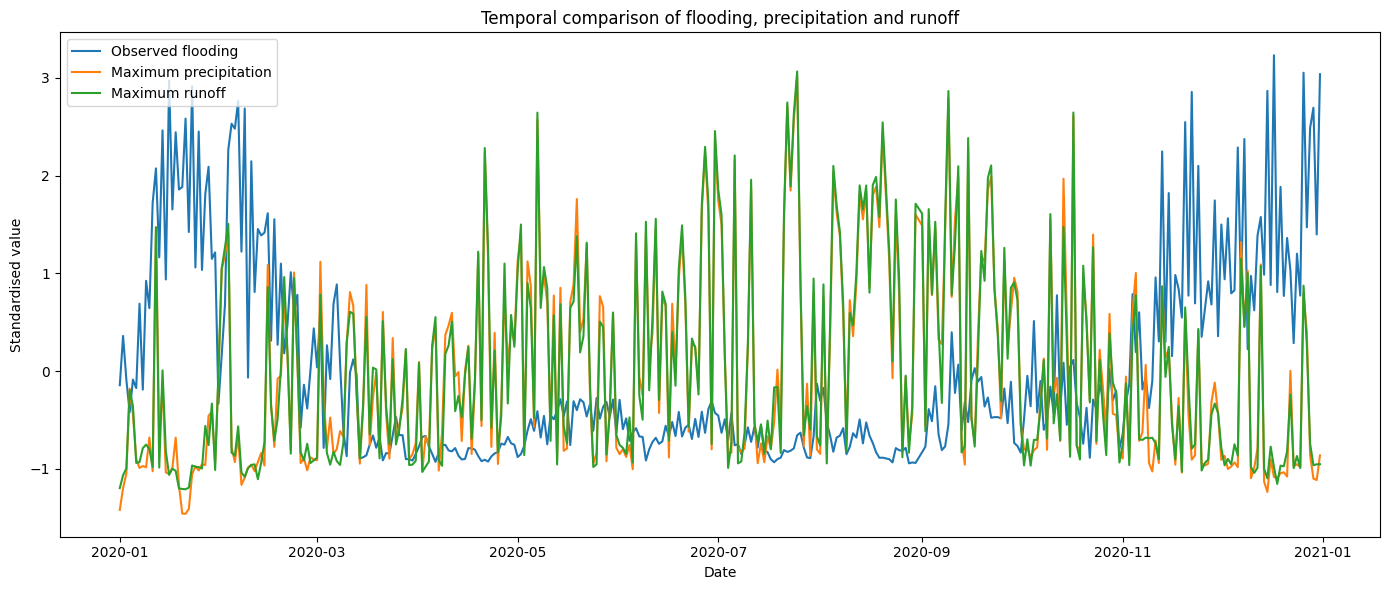

In [35]:
# Compare flooding, precipitation and runoff
standardized_df = (
    analysis_df - analysis_df.mean()
) / analysis_df.std()

plt.figure(figsize=(14, 6))
plt.plot(standardized_df.index, standardized_df["flood_pixels"], label="Observed flooding")
plt.plot(standardized_df.index, standardized_df["precipitation_max_mm"], label="Maximum precipitation")
plt.plot(standardized_df.index, standardized_df["runoff_max_mm"], label="Maximum runoff")
plt.xlabel("Date")
plt.ylabel("Standardised value")
plt.title("Temporal comparison of flooding, precipitation and runoff")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Lag correlation analysis
MAX_LAG = 30
lag_results = []

for lag in range(MAX_LAG + 1):
    shifted_precipitation = analysis_df["precipitation_max_mm"].shift(lag)
    shifted_runoff = analysis_df["runoff_max_mm"].shift(lag)
    precipitation_corr = analysis_df["flood_pixels"].corr(shifted_precipitation)
    runoff_corr = analysis_df["flood_pixels"].corr(shifted_runoff)
    lag_results.append({"lag_days": lag, "precipitation_corr": precipitation_corr, "runoff_corr": runoff_corr})
lag_results_df = pd.DataFrame(lag_results)

print("--- LAG CORRELATION RESULTS ---")
lag_results_df

--- LAG CORRELATION RESULTS ---


,lag_days,precipitation_corr,runoff_corr
0,0,-0.309729,-0.300458
1,1,-0.351897,-0.339575
2,2,-0.285206,-0.275510
3,3,-0.345394,-0.334350
4,4,-0.292837,-0.290070
5,5,-0.326028,-0.318372
6,6,-0.315557,-0.310172
7,7,-0.302274,-0.292368
8,8,-0.307798,-0.297370
9,9,-0.280407,-0.273297


In [41]:
# Find strongest lags
best_precip_lag = lag_results_df.loc[lag_results_df["precipitation_corr"].abs().idxmax()]
best_runoff_lag = lag_results_df.loc[lag_results_df["runoff_corr"].abs().idxmax()]

print("--- STRONGEST PRECIPITATION LAG ---")
print(best_precip_lag)

print("\n--- STRONGEST RUNOFF LAG ---")
print(best_runoff_lag)

--- STRONGEST PRECIPITATION LAG ---
lag_days              1.000000
precipitation_corr   -0.351897
runoff_corr          -0.339575
Name: 1, dtype: float64

--- STRONGEST RUNOFF LAG ---
lag_days              1.000000
precipitation_corr   -0.351897
runoff_corr          -0.339575
Name: 1, dtype: float64


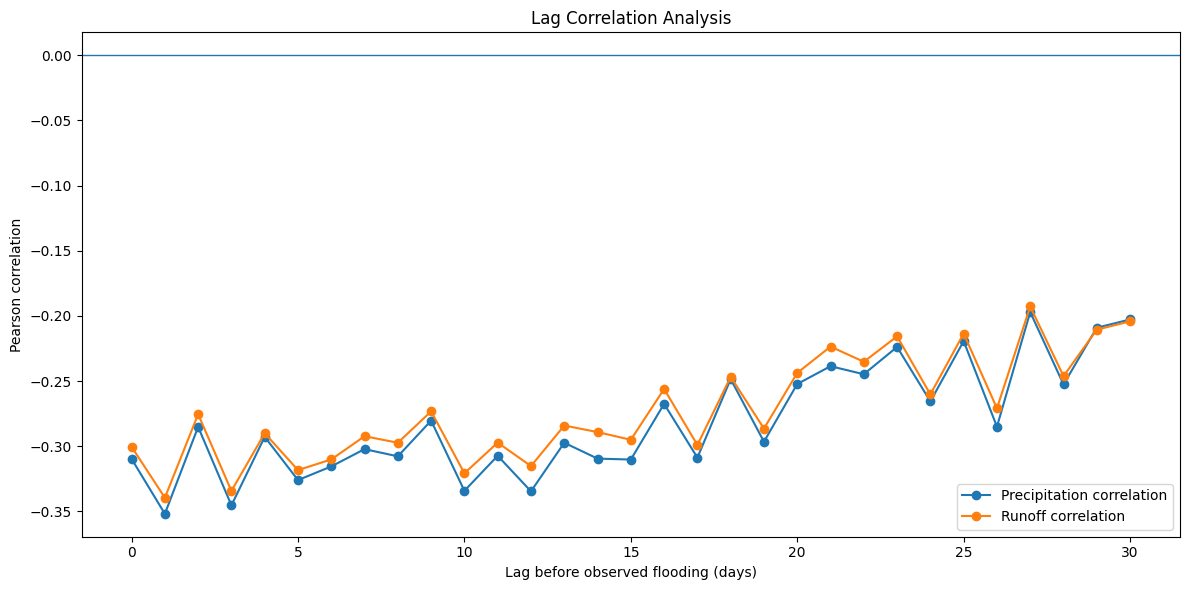

In [37]:
# Visualize lag correlation results
plt.figure(figsize=(12, 6))
plt.plot(lag_results_df["lag_days"], lag_results_df["precipitation_corr"], label="Precipitation correlation", marker='o')
plt.plot(lag_results_df["lag_days"], lag_results_df["runoff_corr"], label="Runoff correlation", marker='o')
plt.axhline(0, linewidth=1)
plt.xlabel("Lag before observed flooding (days)")
plt.ylabel("Pearson correlation")
plt.title("Lag Correlation Analysis")
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# Calculate daily flood changes
analysis_df["flood_change"] = (analysis_df["flood_pixels"].diff())
print("--- DAILY CHANGE IN FLOOD ACTIVITY ---")
print(analysis_df[["flood_pixels", "flood_change"]].head(15))

print("\nSummary statistics:")
print(analysis_df["flood_change"].describe())

--- DAILY CHANGE IN FLOOD ACTIVITY ---
            flood_pixels  flood_change
date                                  
2020-01-01          9275           NaN
2020-01-02         15130        5855.0
2020-01-03          9923       -5207.0
2020-01-04          6058       -3865.0
2020-01-05          9943        3885.0
2020-01-06          8930       -1013.0
2020-01-07         18955       10025.0
2020-01-08          8750      -10205.0
2020-01-09         21669       12919.0
2020-01-10         18426       -3243.0
2020-01-11         30938       12512.0
2020-01-12         35016        4078.0
2020-01-13         24455      -10561.0
2020-01-14         39522       15067.0
2020-01-15         21826      -17696.0

Summary statistics:
count      363.000000
mean       101.716253
std       8208.232956
min     -31942.000000
25%      -2480.500000
50%        162.000000
75%       2626.000000
max      27273.000000
Name: flood_change, dtype: float64


In [42]:
# Lag analysis using changes in flood activity
MAX_LAG = 30
flood_change_lag_results = []

for lag in range(MAX_LAG + 1):
    shifted_precipitation = (analysis_df["precipitation_max_mm"].shift(lag))
    shifted_runoff = (analysis_df["runoff_max_mm"].shift(lag))

    precipitation_corr = (analysis_df["flood_change"].corr(shifted_precipitation))
    runoff_corr = (analysis_df["flood_change"].corr(shifted_runoff))

    flood_change_lag_results.append({"lag_days": lag, "precipitation_corr": precipitation_corr, "runoff_corr": runoff_corr})

flood_change_lag_results_df = pd.DataFrame(flood_change_lag_results)

print("--- LAG CORRELATION WITH FLOOD CHANGE ---")
flood_change_lag_results_df

--- LAG CORRELATION WITH FLOOD CHANGE ---


,lag_days,precipitation_corr,runoff_corr
0,0,0.039105,0.048559
1,1,-0.069509,-0.066186
2,2,0.082170,0.080105
3,3,-0.097855,-0.094473
4,4,0.064784,0.054313
5,5,-0.042299,-0.037117
6,6,0.024654,0.022470
7,7,0.007895,0.014217
8,8,-0.018887,-0.017225
9,9,0.028246,0.023299


In [43]:
# Strongest lags for flood change
strongest_precip_positive = (flood_change_lag_results_df.loc[flood_change_lag_results_df["precipitation_corr"].idxmax()])
strongest_precip_negative = (flood_change_lag_results_df.loc[flood_change_lag_results_df["precipitation_corr"].idxmin()])
strongest_runoff_positive = (flood_change_lag_results_df.loc[flood_change_lag_results_df["runoff_corr"].idxmax()])
strongest_runoff_negative = (flood_change_lag_results_df.loc[flood_change_lag_results_df["runoff_corr"].idxmin()])

print("--- PRECIPITATION: STRONGEST POSITIVE CORRELATION ---")
print(strongest_precip_positive)

print("\n--- PRECIPITATION: STRONGEST NEGATIVE CORRELATION ---")
print(strongest_precip_negative)

print("\n--- RUNOFF: STRONGEST POSITIVE CORRELATION ---")
print(strongest_runoff_positive)

print("\n--- RUNOFF: STRONGEST NEGATIVE CORRELATION ---")
print(strongest_runoff_negative)

--- PRECIPITATION: STRONGEST POSITIVE CORRELATION ---
lag_days              27.000000
precipitation_corr     0.110598
runoff_corr            0.099360
Name: 27, dtype: float64

--- PRECIPITATION: STRONGEST NEGATIVE CORRELATION ---
lag_days              26.000000
precipitation_corr    -0.103778
runoff_corr           -0.090649
Name: 26, dtype: float64

--- RUNOFF: STRONGEST POSITIVE CORRELATION ---
lag_days              27.000000
precipitation_corr     0.110598
runoff_corr            0.099360
Name: 27, dtype: float64

--- RUNOFF: STRONGEST NEGATIVE CORRELATION ---
lag_days              3.000000
precipitation_corr   -0.097855
runoff_corr          -0.094473
Name: 3, dtype: float64


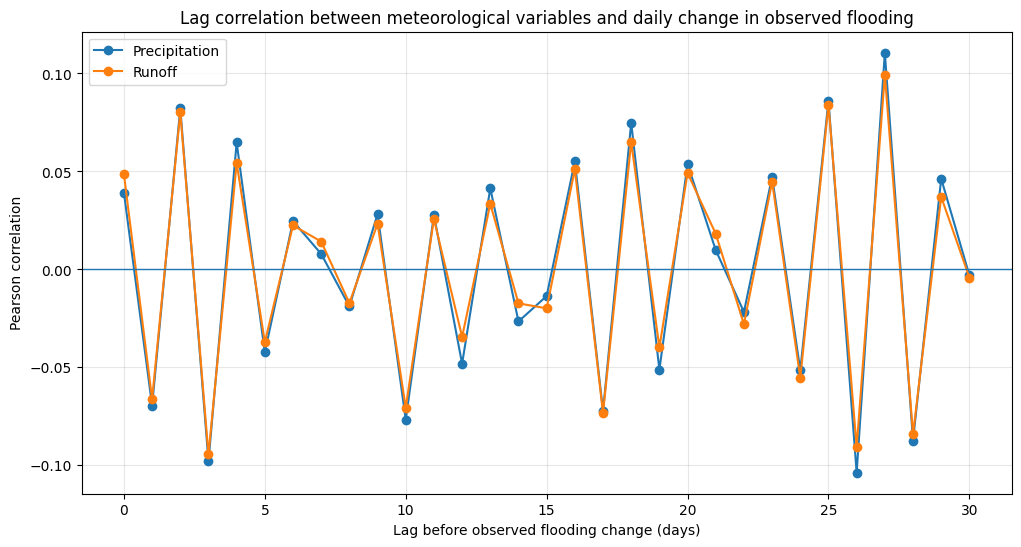

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(flood_change_lag_results_df["lag_days"],flood_change_lag_results_df["precipitation_corr"],marker="o",label="Precipitation")
plt.plot(flood_change_lag_results_df["lag_days"],flood_change_lag_results_df["runoff_corr"],marker="o",label="Runoff")
plt.axhline(0, linewidth=1)
plt.xlabel("Lag before observed flooding change (days)")
plt.ylabel("Pearson correlation")
plt.title("Lag correlation between meteorological variables ""and daily change in observed flooding")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

With the results of the code in this file, we can say the following:

To investigate the relationship between observed flooding and meteorological conditions, daily flood activity was compared with daily maximum precipitation and runoff values from the ERA5 dataset. The analysis was limited to the area where the flood observations and ERA5 data spatially overlap. This ensured that the meteorological variables and flood observations covered approximately the same geographical area.

The temporal comparison shows that flooding, precipitation and runoff vary considerably throughout 2020. However, visual inspection does not reveal a clear and consistent pattern in which increases in precipitation or runoff are immediately followed by increases in observed flooding.

To further investigate potential delayed relationships, lag correlations were calculated for lags between 0 and 30 days. When comparing the total daily number of observed flood pixels with precipitation and runoff, the strongest correlations occurred at a lag of one day. The correlation was approximately −0.352 for precipitation and −0.340 for runoff. Although these correlations are stronger than the correlations at most other lags, their negative direction means that the results should not be interpreted as a simple causal relationship in which higher precipitation directly results in lower flooding.

The analysis was therefore extended by examining the relationship between precipitation and runoff and the daily change in observed flooding. For this analysis, correlations were considerably weaker, ranging approximately between −0.10 and +0.11 across all lags. The strongest positive correlation for precipitation occurred at a lag of 27 days with a correlation of approximately 0.111. The strongest positive correlation for runoff also occurred at a lag of 27 days, with a correlation of approximately 0.099. These values indicate only a very weak linear relationship.

Overall, the results suggest that, at the daily temporal scale and study-area-wide spatial aggregation used in this analysis, precipitation and runoff do not strongly explain day-to-day changes in observed flooding. This does not necessarily mean that meteorological conditions are unrelated to flooding. The relationship may be affected by spatial aggregation, differences between the ERA5 grid and the flood pixel locations, temporal persistence of floodwater, and differences between the locations where precipitation occurs and where flooding is observed.

Conclusion: The analysis does not identify a strong and consistent linear relationship between daily precipitation or runoff and observed flooding across the study area. Meteorological conditions may still contribute to flooding, but their relationship with observed flood activity is likely more spatially and temporally complex than can be captured using study-area-wide daily maximum values and simple lag correlations.